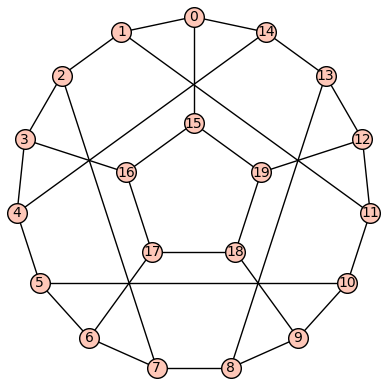

In [ ]:
g = graphs.FlowerSnark()
g.show()

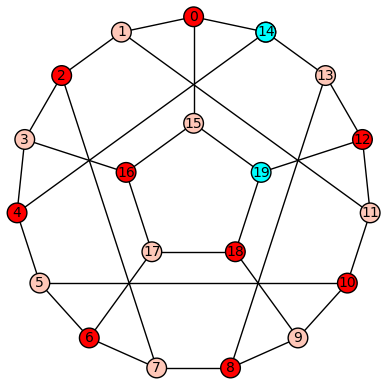

In [2]:
S = [[0, 2, 4, 6, 8, 10, 12, 14, 16, 18], [14, 19]]
g.show(partition = S)

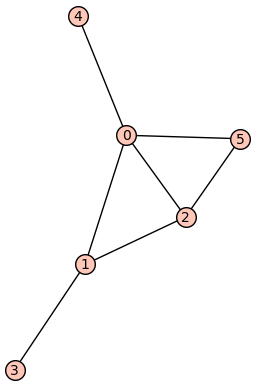

In [5]:
M = matrix([[0,1,1,0,1,1],[1,0,1,1,0,0],[1,1,0,0,0,1],[0,1,0,0,0,0],[1,0,0,0,0,0],[1,0,1,0,0,0]])
g = Graph(M)
g.show()

# Fonctions Utiles

In [ ]:
#trouver les voisins de M

def voisins(M, x):
    p = M.ncols()
    res = []
    for j in range(p):
        if M[x, j] == 1:
            res.append(j)
    return res


#trouver les degrés de M
def degre(M, x):
    L = voisins(M, x)
    if x in L:
        return len(L) + 1
    else:
        return len(L)

# EXERCICE 1:

In [9]:
def color1(M, sommets):
    n = M.nrows()
    partition = []
    for s in sommets:
        partition.append([s])
    autres = []
    for i in range(n):
        if i not in sommets:
            autres.append(i)
    if len(autres) > 0:
        partition.append(autres)
    return partition




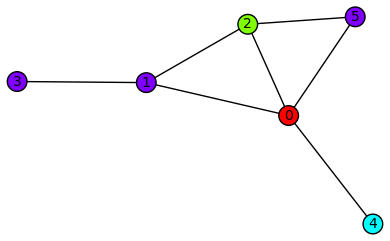

In [12]:
C = color1(M, [0, 2, 4])
g.show(partition = C)

# EXERCICE 2:

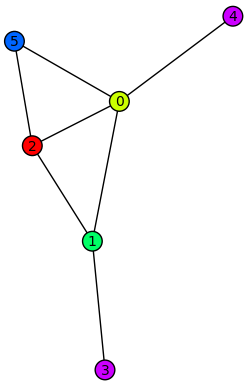

In [16]:
def color2(M, x):
    n = M.nrows()
    
    sommets_colores = [x] + voisins(M, x)
    partition = []
    for s in sommets_colores:
        partition.append([s])
  
    autres = []
    for i in range(n):
        if i not in sommets_colores:
            autres.append(i)
    if len(autres) > 0:
        partition.append(autres)
    return partition

P = color2(M, 2)
g.show(partition = P)

# EXERCICE 3:

In [18]:
def color3(M):
    n = M.nrows()

    degres = []
    for i in range(n):
        degres.append(degre(M, i))
    degre_max = max(degres)
    degre_min = min(degres)
    
    groupe_max = []
    groupe_min = []
    autres = []
    for i in range(n):
        if degres[i] == degre_max:
            groupe_max.append(i)
        elif degres[i] == degre_min:
            groupe_min.append(i)
        else:
            autres.append(i)
    
    partition = [groupe_max, groupe_min]
    if len(autres) > 0:
        partition.append(autres)
    return partition



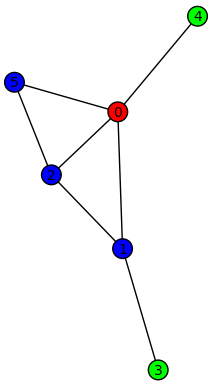

In [19]:
C = color3(M)
g.show(partition = C)

# EXERCICE 4:

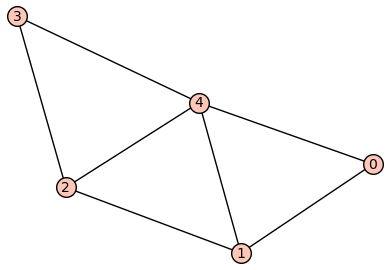

Coloration glouton : [1, 2, 1, 2, 3]
Nombre de couleurs : 3


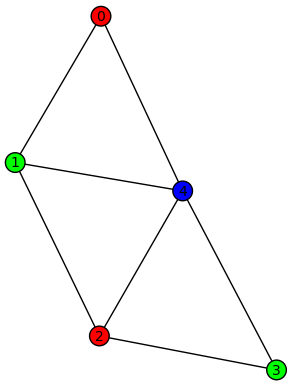

In [ ]:
# 1. matrice d’adjacence M1
M1 = matrix([
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 1],
    [0, 0, 1, 0, 1],
    [1, 1, 1, 1, 0]
])
g1 = Graph(M1)
g1.show()

# 2.  l’algorithme glouton simplifié.

def glouton(M):
    n = M.nrows()
    couleurs = [0] * n  
    for x in range(n):
        
        couleurs_voisins = set()
        for v in voisins(M, x):
            if couleurs[v] != 0:
                couleurs_voisins.add(couleurs[v])
        
        pc = 1
        while pc in couleurs_voisins:
            pc += 1
        couleurs[x] = pc
    return couleurs

print("Coloration glouton :", glouton(M1))
print("Nombre de couleurs :", max(glouton(M1)))


# 3. La coloration est-elle optimale ?

def couleurs_vers_partition(couleurs):
    nb_couleurs = max(couleurs)
    partition = []
    for c in range(1, nb_couleurs + 1):
        groupe = []
        for i in range(len(couleurs)):
            if couleurs[i] == c:
                groupe.append(i)
        if len(groupe) > 0:
            partition.append(groupe)
    return partition

g1.show(partition = couleurs_vers_partition(glouton(M1)))

# conclusion: pas forcément le résultat dépend de l'ordre de parcours des sommets.

# EXERCICE 5


In [26]:
def tri_degre(M, Bool):
    n = M.nrows()
    sommets = list(range(n))
    def degre_sommet(x):
        return degre(M, x)
    sommets.sort(key=degre_sommet, reverse=Bool)
    return sommets

print("Décroissant :", tri_degre(M1, True))
print("Croissant :", tri_degre(M1, False))

Décroissant : [4, 1, 2, 0, 3]
Croissant : [0, 3, 1, 2, 4]


# EXERCICE 6:

Glouton simplifié : [1, 2, 1, 2, 3] -> 3 couleurs
Welsh-Powell      : [3, 2, 3, 4, 1] -> 4 couleurs


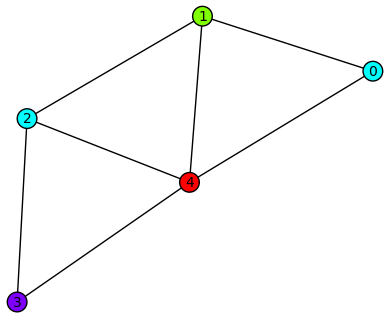

In [32]:
def glouton2(M):
    n = M.nrows()
    couleurs = [0] * n
    # Parcourir les sommets par degré décroissant

    sommets_tries = tri_degre(M, True)
    for x in sommets_tries:
        couleurs_voisins = set()
        for v in voisins(M, x):
            if couleurs[v] != 0:
                couleurs_voisins.add(couleurs[v])
        pc = 1
        for pc in couleurs_voisins:
            pc += 1
        couleurs[x] = pc
    return couleurs

print("Glouton simplifié :", glouton(M1), "->", max(glouton(M1)), "couleurs")
print("Welsh-Powell      :", glouton2(M1), "->", max(glouton2(M1)), "couleurs")
g1.show(partition = couleurs_vers_partition(glouton2(M1)))

# EXERCICE 7:

In [37]:
sud = matrix([
    [0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,0],
    [1,0,1,1,1,1,0,0,0,1,0,0,0,1,0,0],
    [1,1,0,1,0,0,1,1,0,0,1,0,0,0,1,0],
    [1,1,1,0,0,0,1,1,0,0,0,1,0,0,0,1],
    [1,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0],
    [1,1,0,0,1,0,1,1,0,1,0,0,0,1,0,0],
    [0,0,1,1,1,1,0,1,0,0,1,0,0,0,1,0],
    [0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1],
    [1,0,0,0,1,0,0,0,0,1,1,1,1,1,0,0],
    [0,1,0,0,0,1,0,0,1,0,1,1,1,1,0,0],
    [0,0,1,0,0,0,1,0,1,1,0,1,0,0,1,1],
    [0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,1],
    [1,0,0,0,1,0,0,0,1,1,0,0,0,1,1,1],
    [0,1,0,0,0,1,0,0,1,1,0,0,1,0,1,1],
    [0,0,1,0,0,0,1,0,0,0,1,1,1,1,0,1],
    [0,0,0,1,0,0,0,1,0,0,1,1,1,1,1,0]
])

In [39]:
def sudoku(sommets, couleurs):
    n = sud.nrows()
    resultat = [0] * n
    # Placer les couleurs initiales
    for i in range(len(sommets)):
        resultat[sommets[i]] = couleurs[i]
    
    for _ in range(n):
        meilleur = -1
        meilleur_score = -1
        for x in range(n):
            if resultat[x] != 0:
                continue
            score = 0
            for v in voisins(sud, x):
                if resultat[v] != 0:
                    score += 1
            if score > meilleur_score:
                meilleur_score = score
                meilleur = x
        if meilleur == -1:
            break
        couleurs_voisins = set()
        for v in voisins(sud, meilleur):
            if resultat[v] != 0:
                couleurs_voisins.add(resultat[v])
        pc = 1
        while pc in couleurs_voisins:
            pc += 1
        resultat[meilleur] = pc
    return resultat

sudoku([0,2,4,11,13],[1,2,3,4,1])

[1, 4, 2, 3, 3, 2, 4, 1, 2, 3, 1, 4, 4, 1, 3, 2]

# EXERCICE 8:

In [40]:
def sudoku_tableau(sommets, couleurs):
    solution = sudoku(sommets, couleurs)
    for i in range(4):
        ligne = solution[i*4 : (i+1)*4]
        print(ligne)

sudoku_tableau([0,2,4,11,13],[1,2,3,4,1])

[1, 4, 2, 3]
[3, 2, 4, 1]
[2, 3, 1, 4]
[4, 1, 3, 2]
